In [1]:
# ============================================================
# STEP 1: CONNECT GOOGLE DRIVE
# ============================================================

from google.colab import drive

drive.mount('/content/drive')

print("Google Drive connected successfully.")

Mounted at /content/drive
Google Drive connected successfully.


In [2]:
# ============================================================
# STEP 2: IMPORT LIBRARIES AND SET RANDOM SEED
# ============================================================

import os
import json
import random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import sentencepiece as spm

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

# ------------------------------------------------------------
# Device
# ------------------------------------------------------------

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("PyTorch version:", torch.__version__)
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cpu
Device: cpu


In [3]:
# ============================================================
# STEP 3: DEFINE PROJECT PATHS
# ============================================================

PROJECT_ROOT = "/content/drive/MyDrive/NNDL_English_Hindi_Translator"

PROCESSED_DATA_DIR = os.path.join(
    PROJECT_ROOT,
    "data",
    "processed"
)

TOKENIZER_DIR = os.path.join(
    PROJECT_ROOT,
    "tokenizers"
)

MODEL_DIR = os.path.join(
    PROJECT_ROOT,
    "saved_models",
    "gru_attention"
)

RESULTS_PLOTS_DIR = os.path.join(
    PROJECT_ROOT,
    "results",
    "plots"
)

ATTENTION_MAP_DIR = os.path.join(
    PROJECT_ROOT,
    "results",
    "attention_maps"
)

RESULTS_METRICS_DIR = os.path.join(
    PROJECT_ROOT,
    "results",
    "metrics"
)

# ------------------------------------------------------------
# Processed dataset files
# ------------------------------------------------------------

TRAIN_PATH = os.path.join(
    PROCESSED_DATA_DIR,
    "train_clean_300k.parquet"
)

VALIDATION_PATH = os.path.join(
    PROCESSED_DATA_DIR,
    "validation_clean.parquet"
)

# ------------------------------------------------------------
# Tokenizer files
# ------------------------------------------------------------

ENGLISH_TOKENIZER_PATH = os.path.join(
    TOKENIZER_DIR,
    "english_bpe.model"
)

HINDI_TOKENIZER_PATH = os.path.join(
    TOKENIZER_DIR,
    "hindi_bpe.model"
)

CONFIG_PATH = os.path.join(
    TOKENIZER_DIR,
    "tokenizer_config.json"
)

# ------------------------------------------------------------
# Create required output folders
# ------------------------------------------------------------

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULTS_PLOTS_DIR, exist_ok=True)
os.makedirs(ATTENTION_MAP_DIR, exist_ok=True)
os.makedirs(RESULTS_METRICS_DIR, exist_ok=True)

print("Project paths created successfully.")

Project paths created successfully.


In [4]:
# ============================================================
# STEP 4: LOAD SAVED TOKENIZER CONFIGURATION
# ============================================================

with open(
    CONFIG_PATH,
    "r",
    encoding="utf-8"
) as file:

    config = json.load(file)

print("Tokenizer configuration loaded successfully.")

print("\nConfiguration:")
print(
    json.dumps(
        config,
        indent=4,
        ensure_ascii=False
    )
)

Tokenizer configuration loaded successfully.

Configuration:
{
    "training_pairs": 300000,
    "random_seed": 42,
    "english_vocab_size": 16000,
    "hindi_vocab_size": 16000,
    "pad_id": 0,
    "unk_id": 1,
    "bos_id": 2,
    "eos_id": 3,
    "max_sequence_length": 64,
    "max_content_tokens": 62,
    "training_word_length_limit": 50,
    "english_tokenizer": "english_bpe.model",
    "hindi_tokenizer": "hindi_bpe.model"
}


In [5]:
# ============================================================
# STEP 5: EXTRACT IMPORTANT CONFIGURATION VALUES
# ============================================================

PAD_ID = config["pad_id"]
UNK_ID = config["unk_id"]
BOS_ID = config["bos_id"]
EOS_ID = config["eos_id"]

MAX_SEQUENCE_LENGTH = config["max_sequence_length"]

ENGLISH_VOCAB_SIZE = config["english_vocab_size"]
HINDI_VOCAB_SIZE = config["hindi_vocab_size"]

print("PAD_ID:", PAD_ID)
print("UNK_ID:", UNK_ID)
print("BOS_ID:", BOS_ID)
print("EOS_ID:", EOS_ID)

print("\nMAX_SEQUENCE_LENGTH:", MAX_SEQUENCE_LENGTH)

print("\nEnglish vocabulary:", ENGLISH_VOCAB_SIZE)
print("Hindi vocabulary:", HINDI_VOCAB_SIZE)

PAD_ID: 0
UNK_ID: 1
BOS_ID: 2
EOS_ID: 3

MAX_SEQUENCE_LENGTH: 64

English vocabulary: 16000
Hindi vocabulary: 16000


In [6]:
# ============================================================
# STEP 6: LOAD SENTENCEPIECE TOKENIZERS
# ============================================================

english_tokenizer = spm.SentencePieceProcessor()
english_tokenizer.load(
    ENGLISH_TOKENIZER_PATH
)

hindi_tokenizer = spm.SentencePieceProcessor()
hindi_tokenizer.load(
    HINDI_TOKENIZER_PATH
)

print("Both tokenizers loaded successfully.")

print(
    "English tokenizer vocabulary:",
    english_tokenizer.get_piece_size()
)

print(
    "Hindi tokenizer vocabulary:",
    hindi_tokenizer.get_piece_size()
)

Both tokenizers loaded successfully.
English tokenizer vocabulary: 16000
Hindi tokenizer vocabulary: 16000


In [10]:
# ============================================================
# STEP 7: LOAD TRAINING AND VALIDATION DATA
# ============================================================

train_df = pd.read_parquet(
    TRAIN_PATH
)

validation_df = pd.read_parquet(
    VALIDATION_PATH
)

print("Datasets loaded successfully.")

print(f"Training rows   : {len(train_df):,}")
print(f"Validation rows : {len(validation_df):,}")

print("\nTraining columns:")
print(train_df.columns.tolist())

print("\nValidation columns:")
print(validation_df.columns.tolist())

Datasets loaded successfully.
Training rows   : 300,000
Validation rows : 520

Training columns:
['english', 'hindi']

Validation columns:
['english', 'hindi']


In [11]:
# ============================================================
# STEP 8: CREATE SENTENCE ENCODING FUNCTION
# ============================================================

def encode_sentence(
    text,
    tokenizer,
    max_length=MAX_SEQUENCE_LENGTH
):
    """
    Convert a sentence into a fixed-length list of token IDs.

    Steps:
    1. Convert text into SentencePiece token IDs.
    2. Reserve 2 positions for BOS and EOS.
    3. Truncate if necessary.
    4. Add BOS at the beginning.
    5. Add EOS at the end.
    6. Pad to max_length.
    """

    token_ids = tokenizer.encode(
        text,
        out_type=int
    )

    token_ids = token_ids[
        :max_length - 2
    ]

    token_ids = (
        [BOS_ID]
        + token_ids
        + [EOS_ID]
    )

    padding_length = (
        max_length - len(token_ids)
    )

    token_ids = token_ids + (
        [PAD_ID] * padding_length
    )

    return token_ids


print("Sentence encoding function created successfully.")

Sentence encoding function created successfully.


In [12]:
# ============================================================
# STEP 9: CREATE PYTORCH TRANSLATION DATASET
# ============================================================

class TranslationDataset(Dataset):
    """
    PyTorch Dataset for English-to-Hindi translation.
    """

    def __init__(
        self,
        dataframe,
        english_tokenizer,
        hindi_tokenizer
    ):
        self.dataframe = dataframe.reset_index(drop=True)
        self.english_tokenizer = english_tokenizer
        self.hindi_tokenizer = hindi_tokenizer

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):

        english_text = self.dataframe.iloc[index]["english"]
        hindi_text = self.dataframe.iloc[index]["hindi"]

        english_ids = encode_sentence(
            english_text,
            self.english_tokenizer
        )

        hindi_ids = encode_sentence(
            hindi_text,
            self.hindi_tokenizer
        )

        english_tensor = torch.tensor(
            english_ids,
            dtype=torch.long
        )

        hindi_tensor = torch.tensor(
            hindi_ids,
            dtype=torch.long
        )

        return english_tensor, hindi_tensor


print("TranslationDataset class created successfully.")

TranslationDataset class created successfully.


In [13]:
# ============================================================
# STEP 10: CREATE TRAINING AND VALIDATION DATASETS
# ============================================================

train_dataset = TranslationDataset(
    train_df,
    english_tokenizer,
    hindi_tokenizer
)

validation_dataset = TranslationDataset(
    validation_df,
    english_tokenizer,
    hindi_tokenizer
)

print("Datasets created successfully.")

print(f"Training examples   : {len(train_dataset):,}")
print(f"Validation examples : {len(validation_dataset):,}")

Datasets created successfully.
Training examples   : 300,000
Validation examples : 520


In [14]:
# ============================================================
# STEP 11: CREATE PYTORCH DATALOADERS
# ============================================================

BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("DataLoaders created successfully.")

print("Training batches   :", len(train_loader))
print("Validation batches :", len(validation_loader))

DataLoaders created successfully.
Training batches   : 4688
Validation batches : 9


In [15]:
# ============================================================
# STEP 12: DEFINE GRU + ATTENTION HYPERPARAMETERS
# ============================================================

EMBEDDING_DIM = 256
HIDDEN_DIM = 512
ATTENTION_DIM = 512
NUM_LAYERS = 1

print("GRU + BAHDANAU ATTENTION CONFIGURATION")
print("-" * 45)

print("English vocabulary :", ENGLISH_VOCAB_SIZE)
print("Hindi vocabulary   :", HINDI_VOCAB_SIZE)
print("Embedding dimension:", EMBEDDING_DIM)
print("Hidden dimension   :", HIDDEN_DIM)
print("Attention dimension:", ATTENTION_DIM)
print("Number of GRU layers:", NUM_LAYERS)

GRU + BAHDANAU ATTENTION CONFIGURATION
---------------------------------------------
English vocabulary : 16000
Hindi vocabulary   : 16000
Embedding dimension: 256
Hidden dimension   : 512
Attention dimension: 512
Number of GRU layers: 1


In [16]:
# ============================================================
# STEP 13: BUILD BAHDANAU ATTENTION
# ============================================================

class BahdanauAttention(nn.Module):

    def __init__(
        self,
        hidden_dim,
        attention_dim
    ):
        super().__init__()

        # Transform encoder outputs
        self.W_encoder = nn.Linear(
            hidden_dim,
            attention_dim
        )

        # Transform decoder hidden state
        self.W_decoder = nn.Linear(
            hidden_dim,
            attention_dim
        )

        # Convert combined representation into one attention score
        self.V = nn.Linear(
            attention_dim,
            1
        )

    def forward(
        self,
        decoder_hidden,
        encoder_outputs,
        source_mask
    ):
        """
        decoder_hidden:
            [batch_size, hidden_dim]

        encoder_outputs:
            [batch_size, source_length, hidden_dim]

        source_mask:
            [batch_size, source_length]
        """

        # Add sequence dimension to decoder hidden state
        decoder_hidden = decoder_hidden.unsqueeze(1)

        # Calculate alignment energy
        energy = torch.tanh(
            self.W_encoder(encoder_outputs)
            +
            self.W_decoder(decoder_hidden)
        )

        # Convert energy to scalar attention scores
        scores = self.V(
            energy
        ).squeeze(2)

        # Prevent attention from looking at PAD positions
        scores = scores.masked_fill(
            source_mask == 0,
            float("-inf")
        )

        # Convert scores into attention weights
        attention_weights = torch.softmax(
            scores,
            dim=1
        )

        # Weighted sum of encoder outputs
        context_vector = torch.bmm(
            attention_weights.unsqueeze(1),
            encoder_outputs
        ).squeeze(1)

        return context_vector, attention_weights


print("Bahdanau Attention created successfully.")

Bahdanau Attention created successfully.


In [17]:
# ============================================================
# STEP 14: BUILD GRU ENCODER FOR ATTENTION MODEL
# ============================================================

class EncoderGRUAttention(nn.Module):

    def __init__(
        self,
        vocab_size,
        embedding_dim,
        hidden_dim,
        num_layers=1,
        pad_id=0
    ):
        super().__init__()

        self.pad_id = pad_id

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=pad_id
        )

        self.gru = nn.GRU(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )

    def forward(self, source):

        # ----------------------------------------------------
        # Find real sequence lengths
        # ----------------------------------------------------

        lengths = (
            source != self.pad_id
        ).sum(dim=1)

        lengths_cpu = lengths.cpu()

        # ----------------------------------------------------
        # Embedding
        # ----------------------------------------------------

        embedded = self.embedding(
            source
        )

        # ----------------------------------------------------
        # Pack padded sequences
        # ----------------------------------------------------

        packed_embedded = nn.utils.rnn.pack_padded_sequence(
            embedded,
            lengths_cpu,
            batch_first=True,
            enforce_sorted=False
        )

        # ----------------------------------------------------
        # Run GRU
        # ----------------------------------------------------

        packed_outputs, hidden = self.gru(
            packed_embedded
        )

        # ----------------------------------------------------
        # Restore padded sequence shape
        # ----------------------------------------------------

        encoder_outputs, _ = nn.utils.rnn.pad_packed_sequence(
            packed_outputs,
            batch_first=True,
            total_length=source.size(1)
        )

        # ----------------------------------------------------
        # Create source mask
        # 1 = real token
        # 0 = PAD token
        # ----------------------------------------------------

        source_mask = (
            source != self.pad_id
        )

        return (
            encoder_outputs,
            hidden,
            source_mask
        )


print("Attention GRU Encoder created successfully.")

Attention GRU Encoder created successfully.


In [21]:
# ============================================================
# STEP 15: BUILD GRU DECODER WITH BAHDANAU ATTENTION
# ============================================================

class DecoderGRUAttention(nn.Module):

    def __init__(
        self,
        vocab_size,
        embedding_dim,
        hidden_dim,
        attention_dim,
        num_layers=1,
        pad_id=0
    ):
        super().__init__()

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=pad_id
        )

        # Bahdanau attention module
        self.attention = BahdanauAttention(
            hidden_dim=hidden_dim,
            attention_dim=attention_dim
        )

        # Decoder GRU takes:
        # token embedding + context vector
        self.gru = nn.GRU(
            input_size=embedding_dim + hidden_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )

        # Final prediction layer
        self.output_layer = nn.Linear(
            hidden_dim + hidden_dim + embedding_dim,
            vocab_size
        )

    def forward(
        self,
        input_token,
        hidden,
        encoder_outputs,
        source_mask
    ):

        # ----------------------------------------------------
        # Embed current input token
        # ----------------------------------------------------

        embedded = self.embedding(
            input_token
        )

        # embedded shape:
        # [batch_size, embedding_dim]

        # ----------------------------------------------------
        # Get current decoder hidden state
        # ----------------------------------------------------

        decoder_hidden = hidden[-1]

        # ----------------------------------------------------
        # Calculate attention context
        # ----------------------------------------------------

        context_vector, attention_weights = self.attention(
            decoder_hidden,
            encoder_outputs,
            source_mask
        )

        # ----------------------------------------------------
        # Combine token embedding + attention context
        # ----------------------------------------------------

        gru_input = torch.cat(
            [
                embedded,
                context_vector
            ],
            dim=1
        )

        # Add sequence dimension
        gru_input = gru_input.unsqueeze(1)

        # ----------------------------------------------------
        # Run one decoder GRU step
        # ----------------------------------------------------

        output, hidden = self.gru(
            gru_input,
            hidden
        )

        output = output.squeeze(1)

        # ----------------------------------------------------
        # Build final prediction input
        # ----------------------------------------------------

        prediction_input = torch.cat(
            [
                output,
                context_vector,
                embedded
            ],
            dim=1
        )

        # ----------------------------------------------------
        # Predict next Hindi token
        # ----------------------------------------------------

        prediction = self.output_layer(
            prediction_input
        )

        return (
            prediction,
            hidden,
            attention_weights
        )


print("GRU Attention Decoder created successfully.")

GRU Attention Decoder created successfully.


In [18]:
# ============================================================
# STEP 16: BUILD COMPLETE GRU + ATTENTION MODEL
# ============================================================

class Seq2SeqGRUAttention(nn.Module):

    def __init__(
        self,
        encoder,
        decoder
    ):
        super().__init__()

        self.encoder = encoder
        self.decoder = decoder

    def encode(self, source):
        """
        Run the encoder and return:
        1. encoder outputs for every source token
        2. final encoder hidden state
        3. source mask for PAD handling
        """

        encoder_outputs, hidden, source_mask = self.encoder(
            source
        )

        return (
            encoder_outputs,
            hidden,
            source_mask
        )


print("Complete GRU + Attention model class created successfully.")

Complete GRU + Attention model class created successfully.


In [22]:
# ============================================================
# STEP 17: CREATE GRU + BAHDANAU ATTENTION MODEL
# ============================================================

# Create encoder
encoder = EncoderGRUAttention(
    vocab_size=ENGLISH_VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    pad_id=PAD_ID
)

# Create decoder
decoder = DecoderGRUAttention(
    vocab_size=HINDI_VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    attention_dim=ATTENTION_DIM,
    num_layers=NUM_LAYERS,
    pad_id=PAD_ID
)

# Combine encoder and decoder
model = Seq2SeqGRUAttention(
    encoder,
    decoder
).to(device)

print("GRU + Bahdanau Attention model created successfully.")
print(model)

GRU + Bahdanau Attention model created successfully.
Seq2SeqGRUAttention(
  (encoder): EncoderGRUAttention(
    (embedding): Embedding(16000, 256, padding_idx=0)
    (gru): GRU(256, 512, batch_first=True)
  )
  (decoder): DecoderGRUAttention(
    (embedding): Embedding(16000, 256, padding_idx=0)
    (attention): BahdanauAttention(
      (W_encoder): Linear(in_features=512, out_features=512, bias=True)
      (W_decoder): Linear(in_features=512, out_features=512, bias=True)
      (V): Linear(in_features=512, out_features=1, bias=True)
    )
    (gru): GRU(768, 512, batch_first=True)
    (output_layer): Linear(in_features=1280, out_features=16000, bias=True)
  )
)


In [23]:
# ============================================================
# STEP 18: COUNT TRAINABLE PARAMETERS
# ============================================================

def count_parameters(model):
    return sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )

total_parameters = count_parameters(model)

print(
    f"Trainable parameters: "
    f"{total_parameters:,}"
)

Trainable parameters: 32,365,697


In [19]:
# ============================================================
# STEP 19: SANITY CHECK MODEL SHAPES
# ============================================================

# Get one batch
source_batch, target_batch = next(iter(train_loader))

source_batch = source_batch.to(device)
target_batch = target_batch.to(device)

print("Source batch shape :", source_batch.shape)
print("Target batch shape :", target_batch.shape)

# ------------------------------------------------------------
# Run encoder
# ------------------------------------------------------------

encoder_outputs, hidden, source_mask = model.encode(
    source_batch
)

print("\nEncoder outputs shape :", encoder_outputs.shape)
print("Encoder hidden shape  :", hidden.shape)
print("Source mask shape     :", source_mask.shape)

# ------------------------------------------------------------
# Run one decoder step
# Start with BOS token from Hindi target
# ------------------------------------------------------------

decoder_input = target_batch[:, 0]

prediction, new_hidden, attention_weights = model.decoder(
    decoder_input,
    hidden,
    encoder_outputs,
    source_mask
)

print("\nDecoder prediction shape :", prediction.shape)
print("Decoder hidden shape     :", new_hidden.shape)
print("Attention weights shape  :", attention_weights.shape)

# ------------------------------------------------------------
# Check attention probabilities
# They should sum to approximately 1
# ------------------------------------------------------------

print(
    "\nAttention sum for first example:",
    attention_weights[0].sum().item()
)

Source batch shape : torch.Size([64, 64])
Target batch shape : torch.Size([64, 64])

Encoder outputs shape : torch.Size([64, 64, 512])
Encoder hidden shape  : torch.Size([1, 64, 512])
Source mask shape     : torch.Size([64, 64])

Decoder prediction shape : torch.Size([64, 16000])
Decoder hidden shape     : torch.Size([1, 64, 512])
Attention weights shape  : torch.Size([64, 64])

Attention sum for first example: 0.9999999403953552


In [24]:
# ============================================================
# STEP 20: DEFINE OPTIMIZER AND LOSS FUNCTION
# ============================================================

LEARNING_RATE = 0.001

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

# We ignore PAD tokens while calculating loss
criterion = nn.CrossEntropyLoss(
    ignore_index=PAD_ID,
    reduction="sum"
)

print("Optimizer and loss function created successfully.")
print("Learning rate:", LEARNING_RATE)
print("Loss function: CrossEntropyLoss")
print("PAD token ignored:", PAD_ID)

Optimizer and loss function created successfully.
Learning rate: 0.001
Loss function: CrossEntropyLoss
PAD token ignored: 0


In [21]:
# ============================================================
# STEP 21: ONE-BATCH TRAINING SANITY CHECK
# ============================================================

model.train()

# Get one training batch
source_batch, target_batch = next(iter(train_loader))

source_batch = source_batch.to(device)
target_batch = target_batch.to(device)

# Clear old gradients
optimizer.zero_grad()

# ------------------------------------------------------------
# ENCODER
# ------------------------------------------------------------

encoder_outputs, hidden, source_mask = model.encode(
    source_batch
)

# First decoder input = BOS token
decoder_input = target_batch[:, 0]

total_loss = 0.0
total_valid_tokens = 0

# ------------------------------------------------------------
# DECODER LOOP
# ------------------------------------------------------------

for t in range(1, target_batch.size(1)):

    prediction, hidden, attention_weights = model.decoder(
        decoder_input,
        hidden,
        encoder_outputs,
        source_mask
    )

    target_token = target_batch[:, t]

    # Sum loss over non-PAD tokens
    step_loss = criterion(
        prediction,
        target_token
    )

    total_loss += step_loss

    # Count valid target tokens
    valid_tokens = (
        target_token != PAD_ID
    ).sum().item()

    total_valid_tokens += valid_tokens

    # Teacher forcing for this sanity check
    decoder_input = target_token

# ------------------------------------------------------------
# NORMALIZE LOSS
# ------------------------------------------------------------

loss = total_loss / total_valid_tokens

print("Valid Hindi tokens :", total_valid_tokens)
print("Normalized loss    :", loss.item())
print("Loss is finite     :", torch.isfinite(loss).item())

# ------------------------------------------------------------
# BACKPROPAGATION
# ------------------------------------------------------------

loss.backward()

# Gradient clipping
torch.nn.utils.clip_grad_norm_(
    model.parameters(),
    max_norm=1.0
)

optimizer.step()

print("Backward pass and optimizer step completed successfully.")

Valid Hindi tokens : 1285
Normalized loss    : 9.715177536010742
Loss is finite     : True
Backward pass and optimizer step completed successfully.


In [22]:
# ============================================================
# STEP 22: RESET MODEL BEFORE ACTUAL TRAINING
# ============================================================

# Reset seeds so model initialization is reproducible
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)


# ------------------------------------------------------------
# Recreate encoder
# ------------------------------------------------------------

encoder = EncoderGRUAttention(
    vocab_size=ENGLISH_VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    pad_id=PAD_ID
)


# ------------------------------------------------------------
# Recreate decoder
# ------------------------------------------------------------

decoder = DecoderGRUAttention(
    vocab_size=HINDI_VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    attention_dim=ATTENTION_DIM,
    num_layers=NUM_LAYERS,
    pad_id=PAD_ID
)


# ------------------------------------------------------------
# Recreate complete model
# ------------------------------------------------------------

model = Seq2SeqGRUAttention(
    encoder,
    decoder
).to(device)


# ------------------------------------------------------------
# Recreate optimizer
# ------------------------------------------------------------

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)


print("Model reset successfully.")
print("Training will start from clean weights.")
print(f"Trainable parameters: {count_parameters(model):,}")

Model reset successfully.
Training will start from clean weights.
Trainable parameters: 32,365,697


In [23]:
# ============================================================
# STEP 23: CREATE ONE-EPOCH TRAINING FUNCTION
# ============================================================

TEACHER_FORCING_RATIO = 0.5
GRAD_CLIP = 1.0


def train_one_epoch(
    model,
    dataloader,
    optimizer,
    criterion,
    device,
    teacher_forcing_ratio=0.5
):
    """
    Train the GRU + Bahdanau Attention model for one epoch.
    """

    model.train()

    epoch_loss_sum = 0.0
    epoch_valid_tokens = 0

    # --------------------------------------------------------
    # LOOP THROUGH TRAINING BATCHES
    # --------------------------------------------------------

    for source_batch, target_batch in dataloader:

        source_batch = source_batch.to(device)
        target_batch = target_batch.to(device)

        optimizer.zero_grad()

        # ----------------------------------------------------
        # ENCODER
        # ----------------------------------------------------

        encoder_outputs, hidden, source_mask = model.encode(
            source_batch
        )

        # First decoder input is BOS
        decoder_input = target_batch[:, 0]

        batch_loss_sum = 0.0
        batch_valid_tokens = 0

        # ----------------------------------------------------
        # DECODER
        # ----------------------------------------------------

        for t in range(1, target_batch.size(1)):

            prediction, hidden, attention_weights = model.decoder(
                decoder_input,
                hidden,
                encoder_outputs,
                source_mask
            )

            target_token = target_batch[:, t]

            step_loss = criterion(
                prediction,
                target_token
            )

            batch_loss_sum += step_loss

            valid_tokens = (
                target_token != PAD_ID
            ).sum().item()

            batch_valid_tokens += valid_tokens

            # ------------------------------------------------
            # TEACHER FORCING
            # ------------------------------------------------

            use_teacher_forcing = (
                random.random() < teacher_forcing_ratio
            )

            if use_teacher_forcing:
                decoder_input = target_token
            else:
                decoder_input = prediction.argmax(dim=1)

        # ----------------------------------------------------
        # NORMALIZE LOSS BY NON-PAD TOKENS
        # ----------------------------------------------------

        loss = batch_loss_sum / batch_valid_tokens

        # Backpropagation
        loss.backward()

        # Prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            GRAD_CLIP
        )

        optimizer.step()

        # Store totals for epoch loss
        epoch_loss_sum += batch_loss_sum.item()
        epoch_valid_tokens += batch_valid_tokens

    # --------------------------------------------------------
    # FINAL AVERAGE EPOCH LOSS
    # --------------------------------------------------------

    average_epoch_loss = (
        epoch_loss_sum / epoch_valid_tokens
    )

    return average_epoch_loss


print("Training function created successfully.")
print("Teacher forcing ratio:", TEACHER_FORCING_RATIO)
print("Gradient clipping:", GRAD_CLIP)

Training function created successfully.
Teacher forcing ratio: 0.5
Gradient clipping: 1.0


In [24]:
# ============================================================
# STEP 24: CREATE VALIDATION FUNCTION
# ============================================================

def validate_model(
    model,
    dataloader,
    criterion,
    device
):
    """
    Evaluate the GRU + Bahdanau Attention model.

    During validation:
    - No gradient calculation
    - No teacher forcing
    - Model uses its own previous prediction
    """

    model.eval()

    validation_loss_sum = 0.0
    validation_valid_tokens = 0

    # Disable gradient calculation
    with torch.no_grad():

        for source_batch, target_batch in dataloader:

            source_batch = source_batch.to(device)
            target_batch = target_batch.to(device)

            # ------------------------------------------------
            # ENCODER
            # ------------------------------------------------

            encoder_outputs, hidden, source_mask = model.encode(
                source_batch
            )

            # Start decoder with BOS token
            decoder_input = target_batch[:, 0]

            batch_loss_sum = 0.0
            batch_valid_tokens = 0

            # ------------------------------------------------
            # DECODER
            # ------------------------------------------------

            for t in range(1, target_batch.size(1)):

                prediction, hidden, attention_weights = model.decoder(
                    decoder_input,
                    hidden,
                    encoder_outputs,
                    source_mask
                )

                target_token = target_batch[:, t]

                # Calculate loss
                step_loss = criterion(
                    prediction,
                    target_token
                )

                batch_loss_sum += step_loss

                # Count only non-PAD target tokens
                valid_tokens = (
                    target_token != PAD_ID
                ).sum().item()

                batch_valid_tokens += valid_tokens

                # ------------------------------------------------
                # NO TEACHER FORCING DURING VALIDATION
                # Use model's own prediction as next input
                # ------------------------------------------------

                decoder_input = prediction.argmax(
                    dim=1
                )

            validation_loss_sum += batch_loss_sum.item()
            validation_valid_tokens += batch_valid_tokens

    # --------------------------------------------------------
    # NORMALIZED VALIDATION LOSS
    # --------------------------------------------------------

    average_validation_loss = (
        validation_loss_sum /
        validation_valid_tokens
    )

    return average_validation_loss


print("Validation function created successfully.")
print("Validation uses teacher forcing: False")

Validation function created successfully.
Validation uses teacher forcing: False


In [25]:
# ============================================================
# STEP 26: FASTER ONE-EPOCH TRAINING FUNCTION
# ============================================================

def train_one_epoch_fast(
    model,
    dataloader,
    optimizer,
    criterion,
    device,
    teacher_forcing_ratio=0.5
):
    """
    Faster training version.

    Main improvement:
    Only decode up to the longest real target sentence
    in the current batch instead of always using all 64 steps.
    """

    model.train()

    epoch_loss_sum = 0.0
    epoch_valid_tokens = 0

    for source_batch, target_batch in dataloader:

        source_batch = source_batch.to(device)
        target_batch = target_batch.to(device)

        optimizer.zero_grad()

        # ----------------------------------------------------
        # ENCODER
        # ----------------------------------------------------

        encoder_outputs, hidden, source_mask = model.encode(
            source_batch
        )

        decoder_input = target_batch[:, 0]

        batch_loss_sum = 0.0
        batch_valid_tokens = 0

        # ----------------------------------------------------
        # FIND LONGEST REAL TARGET LENGTH IN THIS BATCH
        # ----------------------------------------------------

        target_lengths = (
            target_batch != PAD_ID
        ).sum(dim=1)

        max_target_length = int(
            target_lengths.max().item()
        )

        # ----------------------------------------------------
        # DECODER LOOP
        # ----------------------------------------------------

        for t in range(1, max_target_length):

            prediction, hidden, attention_weights = model.decoder(
                decoder_input,
                hidden,
                encoder_outputs,
                source_mask
            )

            target_token = target_batch[:, t]

            step_loss = criterion(
                prediction,
                target_token
            )

            batch_loss_sum += step_loss

            valid_tokens = (
                target_token != PAD_ID
            ).sum().item()

            batch_valid_tokens += valid_tokens

            # Teacher forcing
            if random.random() < teacher_forcing_ratio:
                decoder_input = target_token
            else:
                decoder_input = prediction.argmax(dim=1)

        # ----------------------------------------------------
        # LOSS
        # ----------------------------------------------------

        loss = (
            batch_loss_sum /
            batch_valid_tokens
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            GRAD_CLIP
        )

        optimizer.step()

        epoch_loss_sum += batch_loss_sum.item()
        epoch_valid_tokens += batch_valid_tokens

    average_epoch_loss = (
        epoch_loss_sum /
        epoch_valid_tokens
    )

    return average_epoch_loss


print("Fast training function created successfully.")

Fast training function created successfully.


In [26]:
# ============================================================
# STEP 27: RESET MODEL BEFORE FAST TRAINING
# ============================================================

# Reset random seeds
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)


# Recreate encoder
encoder = EncoderGRUAttention(
    vocab_size=ENGLISH_VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    pad_id=PAD_ID
)


# Recreate decoder
decoder = DecoderGRUAttention(
    vocab_size=HINDI_VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    attention_dim=ATTENTION_DIM,
    num_layers=NUM_LAYERS,
    pad_id=PAD_ID
)


# Recreate complete model
model = Seq2SeqGRUAttention(
    encoder,
    decoder
).to(device)


# Recreate optimizer
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)


print("Model reset successfully for fast training.")
print(f"Trainable parameters: {count_parameters(model):,}")

Model reset successfully for fast training.
Trainable parameters: 32,365,697


In [19]:
# ============================================================
# STEP 28: CREATE MORE EFFICIENT ATTENTION DECODER
# ============================================================

class DecoderGRUAttention(nn.Module):

    def __init__(
        self,
        vocab_size,
        embedding_dim,
        hidden_dim,
        attention_dim,
        num_layers=1,
        pad_id=0
    ):
        super().__init__()

        # ----------------------------------------------------
        # TOKEN EMBEDDING
        # ----------------------------------------------------

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=pad_id
        )

        # ----------------------------------------------------
        # BAHDANAU ATTENTION
        # ----------------------------------------------------

        self.attention = BahdanauAttention(
            hidden_dim=hidden_dim,
            attention_dim=attention_dim
        )

        # ----------------------------------------------------
        # DECODER GRU
        #
        # Input =
        # token embedding + attention context
        # ----------------------------------------------------

        self.gru = nn.GRU(
            input_size=embedding_dim + hidden_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )

        # ----------------------------------------------------
        # EFFICIENT OUTPUT PROJECTION
        #
        # Instead of:
        # 1280 directly -> 16000
        #
        # We use:
        # 1280 -> 512 -> 16000
        #
        # This significantly reduces computation.
        # ----------------------------------------------------

        self.pre_output = nn.Linear(
            hidden_dim + hidden_dim + embedding_dim,
            hidden_dim
        )

        self.output_layer = nn.Linear(
            hidden_dim,
            vocab_size
        )

    def forward(
        self,
        input_token,
        hidden,
        encoder_outputs,
        source_mask
    ):

        # ----------------------------------------------------
        # EMBED CURRENT TOKEN
        # ----------------------------------------------------

        embedded = self.embedding(
            input_token
        )

        # ----------------------------------------------------
        # CURRENT DECODER HIDDEN STATE
        # ----------------------------------------------------

        decoder_hidden = hidden[-1]

        # ----------------------------------------------------
        # CALCULATE ATTENTION
        # ----------------------------------------------------

        context_vector, attention_weights = self.attention(
            decoder_hidden,
            encoder_outputs,
            source_mask
        )

        # ----------------------------------------------------
        # GRU INPUT
        # ----------------------------------------------------

        gru_input = torch.cat(
            [
                embedded,
                context_vector
            ],
            dim=1
        ).unsqueeze(1)

        # ----------------------------------------------------
        # RUN DECODER GRU
        # ----------------------------------------------------

        output, hidden = self.gru(
            gru_input,
            hidden
        )

        output = output.squeeze(1)

        # ----------------------------------------------------
        # COMBINE DECODER INFORMATION
        # ----------------------------------------------------

        combined = torch.cat(
            [
                output,
                context_vector,
                embedded
            ],
            dim=1
        )

        # Reduce dimensions before vocabulary prediction
        combined = torch.tanh(
            self.pre_output(combined)
        )

        # Predict next Hindi token
        prediction = self.output_layer(
            combined
        )

        return (
            prediction,
            hidden,
            attention_weights
        )


print("Efficient GRU Attention Decoder created successfully.")

Efficient GRU Attention Decoder created successfully.


In [25]:
# ============================================================
# STEP 29: RECREATE MODEL WITH EFFICIENT DECODER
# ============================================================

# Reset seeds
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)


# Recreate encoder
encoder = EncoderGRUAttention(
    vocab_size=ENGLISH_VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    pad_id=PAD_ID
)


# Recreate efficient decoder
decoder = DecoderGRUAttention(
    vocab_size=HINDI_VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    attention_dim=ATTENTION_DIM,
    num_layers=NUM_LAYERS,
    pad_id=PAD_ID
)


# Combine model
model = Seq2SeqGRUAttention(
    encoder,
    decoder
).to(device)


# Recreate optimizer
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)


print("Efficient GRU + Attention model created successfully.")
print(f"Trainable parameters: {count_parameters(model):,}")

Efficient GRU + Attention model created successfully.
Trainable parameters: 32,365,697


In [29]:
# ============================================================
# STEP 30: FAST TRAINING WITH MIXED PRECISION
# ============================================================

# Mixed precision scaler for CUDA GPU
scaler = torch.amp.GradScaler(
    "cuda",
    enabled=(device.type == "cuda")
)


def train_one_epoch_amp(
    model,
    dataloader,
    optimizer,
    criterion,
    device,
    teacher_forcing_ratio=0.5
):
    """
    Optimized training function.

    Improvements:
    1. Only processes real target sequence length.
    2. Uses mixed precision on GPU.
    3. Uses gradient scaling for stable FP16 training.
    """

    model.train()

    epoch_loss_sum = 0.0
    epoch_valid_tokens = 0

    for source_batch, target_batch in dataloader:

        source_batch = source_batch.to(
            device,
            non_blocking=True
        )

        target_batch = target_batch.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        # ----------------------------------------------------
        # LONGEST REAL TARGET IN THIS BATCH
        # ----------------------------------------------------

        target_lengths = (
            target_batch != PAD_ID
        ).sum(dim=1)

        max_target_length = int(
            target_lengths.max().item()
        )

        # ----------------------------------------------------
        # MIXED PRECISION FORWARD PASS
        # ----------------------------------------------------

        with torch.amp.autocast(
            device_type=device.type,
            dtype=torch.float16,
            enabled=(device.type == "cuda")
        ):

            # Encoder
            encoder_outputs, hidden, source_mask = model.encode(
                source_batch
            )

            # First decoder input = BOS
            decoder_input = target_batch[:, 0]

            batch_loss_sum = 0.0
            batch_valid_tokens = 0

            # ------------------------------------------------
            # DECODER
            # ------------------------------------------------

            for t in range(1, max_target_length):

                prediction, hidden, attention_weights = model.decoder(
                    decoder_input,
                    hidden,
                    encoder_outputs,
                    source_mask
                )

                target_token = target_batch[:, t]

                step_loss = criterion(
                    prediction,
                    target_token
                )

                batch_loss_sum = (
                    batch_loss_sum + step_loss
                )

                valid_tokens = (
                    target_token != PAD_ID
                ).sum().item()

                batch_valid_tokens += valid_tokens

                # Teacher forcing
                if random.random() < teacher_forcing_ratio:
                    decoder_input = target_token
                else:
                    decoder_input = prediction.argmax(dim=1)

            loss = (
                batch_loss_sum /
                batch_valid_tokens
            )

        # ----------------------------------------------------
        # BACKPROPAGATION WITH GRADIENT SCALING
        # ----------------------------------------------------

        scaler.scale(
            loss
        ).backward()

        # Unscale before gradient clipping
        scaler.unscale_(
            optimizer
        )

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            GRAD_CLIP
        )

        scaler.step(
            optimizer
        )

        scaler.update()

        # ----------------------------------------------------
        # SAVE LOSS TOTALS
        # ----------------------------------------------------

        epoch_loss_sum += (
            batch_loss_sum.detach().float().item()
        )

        epoch_valid_tokens += (
            batch_valid_tokens
        )

    average_epoch_loss = (
        epoch_loss_sum /
        epoch_valid_tokens
    )

    return average_epoch_loss


print("Optimized mixed-precision training function created.")
print("Mixed precision enabled:", device.type == "cuda")

Optimized mixed-precision training function created.
Mixed precision enabled: True


In [30]:
# ============================================================
# STEP 31: SPEED TEST ON 50 TRAINING BATCHES
# ============================================================

import time

model.train()

TEST_BATCHES = 50

start_time = time.time()

processed_batches = 0

for source_batch, target_batch in train_loader:

    source_batch = source_batch.to(
        device,
        non_blocking=True
    )

    target_batch = target_batch.to(
        device,
        non_blocking=True
    )

    optimizer.zero_grad(
        set_to_none=True
    )

    # Find longest real target length in this batch
    target_lengths = (
        target_batch != PAD_ID
    ).sum(dim=1)

    max_target_length = int(
        target_lengths.max().item()
    )

    # Mixed precision forward pass
    with torch.amp.autocast(
        device_type=device.type,
        dtype=torch.float16,
        enabled=(device.type == "cuda")
    ):

        encoder_outputs, hidden, source_mask = model.encode(
            source_batch
        )

        decoder_input = target_batch[:, 0]

        batch_loss_sum = 0.0
        batch_valid_tokens = 0

        for t in range(1, max_target_length):

            prediction, hidden, attention_weights = model.decoder(
                decoder_input,
                hidden,
                encoder_outputs,
                source_mask
            )

            target_token = target_batch[:, t]

            step_loss = criterion(
                prediction,
                target_token
            )

            batch_loss_sum += step_loss

            batch_valid_tokens += (
                target_token != PAD_ID
            ).sum().item()

            # Teacher forcing
            if random.random() < TEACHER_FORCING_RATIO:
                decoder_input = target_token
            else:
                decoder_input = prediction.argmax(dim=1)

        loss = (
            batch_loss_sum /
            batch_valid_tokens
        )

    # Backpropagation
    scaler.scale(loss).backward()

    scaler.unscale_(optimizer)

    torch.nn.utils.clip_grad_norm_(
        model.parameters(),
        GRAD_CLIP
    )

    scaler.step(optimizer)
    scaler.update()

    processed_batches += 1

    if processed_batches >= TEST_BATCHES:
        break


elapsed_seconds = time.time() - start_time

seconds_per_batch = (
    elapsed_seconds / TEST_BATCHES
)

estimated_epoch_minutes = (
    seconds_per_batch * len(train_loader)
) / 60


print("Speed test completed.")
print(f"50 batches time        : {elapsed_seconds:.2f} seconds")
print(f"Seconds per batch      : {seconds_per_batch:.3f}")
print(f"Estimated epoch time   : {estimated_epoch_minutes:.2f} minutes")

Speed test completed.
50 batches time        : 13.91 seconds
Seconds per batch      : 0.278
Estimated epoch time   : 21.74 minutes


In [32]:
# ============================================================
# STEP 32: CREATE LARGER-BATCH TRAINING DATALOADER
# ============================================================

FAST_BATCH_SIZE = 128

train_loader_fast = DataLoader(
    train_dataset,
    batch_size=FAST_BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

print("Fast training DataLoader created successfully.")
print("Batch size       :", FAST_BATCH_SIZE)
print("Training batches :", len(train_loader_fast))

Fast training DataLoader created successfully.
Batch size       : 128
Training batches : 2344


In [33]:
# ============================================================
# STEP 33: SPEED TEST WITH BATCH SIZE 128
# ============================================================

import time

model.train()

TEST_BATCHES = 25

start_time = time.time()

processed_batches = 0

for source_batch, target_batch in train_loader_fast:

    source_batch = source_batch.to(
        device,
        non_blocking=True
    )

    target_batch = target_batch.to(
        device,
        non_blocking=True
    )

    optimizer.zero_grad(
        set_to_none=True
    )

    # Longest real Hindi sequence in this batch
    target_lengths = (
        target_batch != PAD_ID
    ).sum(dim=1)

    max_target_length = int(
        target_lengths.max().item()
    )

    # Mixed precision
    with torch.amp.autocast(
        device_type=device.type,
        dtype=torch.float16,
        enabled=(device.type == "cuda")
    ):

        encoder_outputs, hidden, source_mask = model.encode(
            source_batch
        )

        decoder_input = target_batch[:, 0]

        batch_loss_sum = 0.0
        batch_valid_tokens = 0

        for t in range(1, max_target_length):

            prediction, hidden, attention_weights = model.decoder(
                decoder_input,
                hidden,
                encoder_outputs,
                source_mask
            )

            target_token = target_batch[:, t]

            step_loss = criterion(
                prediction,
                target_token
            )

            batch_loss_sum += step_loss

            batch_valid_tokens += (
                target_token != PAD_ID
            ).sum().item()

            if random.random() < TEACHER_FORCING_RATIO:
                decoder_input = target_token
            else:
                decoder_input = prediction.argmax(dim=1)

        loss = (
            batch_loss_sum /
            batch_valid_tokens
        )

    # Backpropagation
    scaler.scale(loss).backward()

    scaler.unscale_(optimizer)

    torch.nn.utils.clip_grad_norm_(
        model.parameters(),
        GRAD_CLIP
    )

    scaler.step(optimizer)
    scaler.update()

    processed_batches += 1

    if processed_batches >= TEST_BATCHES:
        break


elapsed_seconds = time.time() - start_time

seconds_per_batch = (
    elapsed_seconds / TEST_BATCHES
)

estimated_epoch_minutes = (
    seconds_per_batch * len(train_loader_fast)
) / 60


print("Batch size 128 speed test completed.")
print(f"25 batches time      : {elapsed_seconds:.2f} seconds")
print(f"Seconds per batch    : {seconds_per_batch:.3f}")
print(f"Estimated epoch time : {estimated_epoch_minutes:.2f} minutes")

Batch size 128 speed test completed.
25 batches time      : 9.47 seconds
Seconds per batch    : 0.379
Estimated epoch time : 14.80 minutes


In [34]:
# ============================================================
# STEP 34: FINAL CLEAN RESET BEFORE REAL TRAINING
# ============================================================

# Reset all random seeds
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)


# Recreate encoder
encoder = EncoderGRUAttention(
    vocab_size=ENGLISH_VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    pad_id=PAD_ID
)


# Recreate efficient decoder
decoder = DecoderGRUAttention(
    vocab_size=HINDI_VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    attention_dim=ATTENTION_DIM,
    num_layers=NUM_LAYERS,
    pad_id=PAD_ID
)


# Recreate complete model
model = Seq2SeqGRUAttention(
    encoder,
    decoder
).to(device)


# Recreate optimizer
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)


# Recreate mixed-precision scaler
scaler = torch.amp.GradScaler(
    "cuda",
    enabled=(device.type == "cuda")
)


print("Final clean model reset completed.")
print(f"Trainable parameters : {count_parameters(model):,}")
print("Final batch size     :", FAST_BATCH_SIZE)
print("Training batches     :", len(train_loader_fast))

Final clean model reset completed.
Trainable parameters : 20,733,569
Final batch size     : 128
Training batches     : 2344


In [35]:
# ============================================================
# STEP 35: FINAL GRU + BAHDANAU ATTENTION TRAINING
# ============================================================

import time

MAX_EPOCHS = 10
PATIENCE = 3

BEST_MODEL_PATH = os.path.join(
    MODEL_DIR,
    "gru_bahdanau_best.pt"
)

HISTORY_PATH = os.path.join(
    RESULTS_METRICS_DIR,
    "gru_attention_training_history.csv"
)

best_validation_loss = float("inf")
best_epoch = 0

epochs_without_improvement = 0

training_history = []

print("=" * 65)
print("FINAL GRU + BAHDANAU ATTENTION TRAINING")
print("=" * 65)

print(f"Training pairs      : {len(train_dataset):,}")
print(f"Batch size          : {FAST_BATCH_SIZE}")
print(f"Training batches    : {len(train_loader_fast):,}")
print(f"Trainable parameters: {count_parameters(model):,}")
print(f"Maximum epochs      : {MAX_EPOCHS}")
print(f"Early stop patience : {PATIENCE}")
print("Mixed precision     : True")

print("=" * 65)

training_start_time = time.time()


# ============================================================
# EPOCH LOOP
# ============================================================

for epoch in range(1, MAX_EPOCHS + 1):

    epoch_start_time = time.time()

    print(f"\nEpoch {epoch}/{MAX_EPOCHS}")
    print("-" * 65)

    # --------------------------------------------------------
    # TRAINING
    # --------------------------------------------------------

    train_loss = train_one_epoch_amp(
        model=model,
        dataloader=train_loader_fast,
        optimizer=optimizer,
        criterion=criterion,
        device=device,
        teacher_forcing_ratio=TEACHER_FORCING_RATIO
    )

    print(
        f"Training completed | "
        f"Loss: {train_loss:.4f}"
    )

    # --------------------------------------------------------
    # VALIDATION
    # --------------------------------------------------------

    validation_loss = validate_model(
        model=model,
        dataloader=validation_loader,
        criterion=criterion,
        device=device
    )

    epoch_minutes = (
        time.time() - epoch_start_time
    ) / 60

    # --------------------------------------------------------
    # SAVE HISTORY
    # --------------------------------------------------------

    training_history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "validation_loss": validation_loss,
        "epoch_minutes": epoch_minutes
    })

    history_df = pd.DataFrame(
        training_history
    )

    history_df.to_csv(
        HISTORY_PATH,
        index=False
    )

    # --------------------------------------------------------
    # PRINT EPOCH RESULT
    # --------------------------------------------------------

    print(
        f"Epoch {epoch:02d} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {validation_loss:.4f} | "
        f"Time: {epoch_minutes:.2f} min"
    )

    # --------------------------------------------------------
    # BEST MODEL CHECK
    # --------------------------------------------------------

    if validation_loss < best_validation_loss:

        best_validation_loss = validation_loss
        best_epoch = epoch

        epochs_without_improvement = 0

        # ----------------------------------------------------
        # SAVE BEST CHECKPOINT
        # ----------------------------------------------------

        torch.save(
            {
                "epoch": epoch,

                "model_state_dict":
                    model.state_dict(),

                "optimizer_state_dict":
                    optimizer.state_dict(),

                "validation_loss":
                    validation_loss,

                "model_config": {
                    "english_vocab_size":
                        ENGLISH_VOCAB_SIZE,

                    "hindi_vocab_size":
                        HINDI_VOCAB_SIZE,

                    "embedding_dim":
                        EMBEDDING_DIM,

                    "hidden_dim":
                        HIDDEN_DIM,

                    "attention_dim":
                        ATTENTION_DIM,

                    "num_layers":
                        NUM_LAYERS,

                    "pad_id":
                        PAD_ID,

                    "batch_size":
                        FAST_BATCH_SIZE
                }
            },
            BEST_MODEL_PATH
        )

        print(
            f"✓ New best model saved "
            f"(Val Loss: {validation_loss:.4f})"
        )

    else:

        epochs_without_improvement += 1

        print(
            f"No validation improvement "
            f"({epochs_without_improvement}/{PATIENCE})"
        )

    # --------------------------------------------------------
    # EARLY STOPPING
    # --------------------------------------------------------

    if epochs_without_improvement >= PATIENCE:

        print("\nEarly stopping triggered.")
        break


# ============================================================
# TRAINING COMPLETE
# ============================================================

total_training_minutes = (
    time.time() - training_start_time
) / 60


print("\n" + "=" * 65)
print("MODEL 2 TRAINING COMPLETE")
print("=" * 65)

print(
    f"Best epoch           : {best_epoch}"
)

print(
    f"Best validation loss : {best_validation_loss:.4f}"
)

print(
    f"Total training time  : {total_training_minutes:.2f} minutes"
)

print(
    f"Best checkpoint      : {BEST_MODEL_PATH}"
)

print(
    f"Training history     : {HISTORY_PATH}"
)

FINAL GRU + BAHDANAU ATTENTION TRAINING
Training pairs      : 300,000
Batch size          : 128
Training batches    : 2,344
Trainable parameters: 20,733,569
Maximum epochs      : 10
Early stop patience : 3
Mixed precision     : True

Epoch 1/10
-----------------------------------------------------------------
Training completed | Loss: 5.9354
Epoch 01 | Train Loss: 5.9354 | Val Loss: 6.7890 | Time: 11.58 min
✓ New best model saved (Val Loss: 6.7890)

Epoch 2/10
-----------------------------------------------------------------
Training completed | Loss: 5.0320
Epoch 02 | Train Loss: 5.0320 | Val Loss: 6.5988 | Time: 11.40 min
✓ New best model saved (Val Loss: 6.5988)

Epoch 3/10
-----------------------------------------------------------------
Training completed | Loss: 4.6465
Epoch 03 | Train Loss: 4.6465 | Val Loss: 6.5728 | Time: 11.45 min
✓ New best model saved (Val Loss: 6.5728)

Epoch 4/10
-----------------------------------------------------------------
Training completed | Loss:

In [27]:
# ============================================================
# RESTORE BEST MODEL PATH
# ============================================================

BEST_MODEL_PATH = os.path.join(
    MODEL_DIR,
    "gru_bahdanau_best.pt"
)

print("Best model path restored:")
print(BEST_MODEL_PATH)

Best model path restored:
/content/drive/MyDrive/NNDL_English_Hindi_Translator/saved_models/gru_attention/gru_bahdanau_best.pt


In [32]:
# ============================================================
# RECOVER FINAL MODEL 2 ARCHITECTURE + LOAD BEST CHECKPOINT
# ============================================================

import os
import torch
import torch.nn as nn


# ------------------------------------------------------------
# 1. DEFINE THE EXACT EFFICIENT DECODER USED FOR TRAINING
# ------------------------------------------------------------

class DecoderGRUAttention(nn.Module):

    def __init__(
        self,
        vocab_size,
        embedding_dim,
        hidden_dim,
        attention_dim,
        num_layers=1,
        pad_id=0
    ):
        super().__init__()

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=pad_id
        )

        self.attention = BahdanauAttention(
            hidden_dim=hidden_dim,
            attention_dim=attention_dim
        )

        self.gru = nn.GRU(
            input_size=embedding_dim + hidden_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )

        # IMPORTANT:
        # This layer must exist because it is in the saved checkpoint
        self.pre_output = nn.Linear(
            hidden_dim + hidden_dim + embedding_dim,
            hidden_dim
        )

        # Final vocabulary layer
        self.output_layer = nn.Linear(
            hidden_dim,
            vocab_size
        )

    def forward(
        self,
        input_token,
        hidden,
        encoder_outputs,
        source_mask
    ):

        embedded = self.embedding(
            input_token
        )

        decoder_hidden = hidden[-1]

        context_vector, attention_weights = self.attention(
            decoder_hidden,
            encoder_outputs,
            source_mask
        )

        gru_input = torch.cat(
            [
                embedded,
                context_vector
            ],
            dim=1
        ).unsqueeze(1)

        output, hidden = self.gru(
            gru_input,
            hidden
        )

        output = output.squeeze(1)

        combined = torch.cat(
            [
                output,
                context_vector,
                embedded
            ],
            dim=1
        )

        combined = torch.tanh(
            self.pre_output(combined)
        )

        prediction = self.output_layer(
            combined
        )

        return (
            prediction,
            hidden,
            attention_weights
        )


# ------------------------------------------------------------
# 2. RECREATE ENCODER
# ------------------------------------------------------------

encoder = EncoderGRUAttention(
    vocab_size=ENGLISH_VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    pad_id=PAD_ID
)


# ------------------------------------------------------------
# 3. RECREATE FINAL EFFICIENT DECODER
# ------------------------------------------------------------

decoder = DecoderGRUAttention(
    vocab_size=HINDI_VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    attention_dim=ATTENTION_DIM,
    num_layers=NUM_LAYERS,
    pad_id=PAD_ID
)


# ------------------------------------------------------------
# 4. RECREATE COMPLETE MODEL
# ------------------------------------------------------------

model = Seq2SeqGRUAttention(
    encoder,
    decoder
).to(device)


# ------------------------------------------------------------
# 5. VERIFY PARAMETER COUNT
# ------------------------------------------------------------

total_parameters = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(
    f"Trainable parameters: {total_parameters:,}"
)


# ------------------------------------------------------------
# 6. RESTORE CHECKPOINT PATH
# ------------------------------------------------------------

BEST_MODEL_PATH = os.path.join(
    MODEL_DIR,
    "gru_bahdanau_best.pt"
)


# ------------------------------------------------------------
# 7. LOAD BEST CHECKPOINT
# ------------------------------------------------------------

checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=device
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.eval()


# ------------------------------------------------------------
# 8. CONFIRM
# ------------------------------------------------------------

print("\nBest checkpoint loaded successfully.")
print("Best epoch           :", checkpoint["epoch"])
print("Best validation loss :", checkpoint["validation_loss"])
print("Checkpoint path      :", BEST_MODEL_PATH)

Trainable parameters: 20,733,569

Best checkpoint loaded successfully.
Best epoch           : 4
Best validation loss : 6.520715561180102
Checkpoint path      : /content/drive/MyDrive/NNDL_English_Hindi_Translator/saved_models/gru_attention/gru_bahdanau_best.pt


In [33]:
# ============================================================
# STEP 36: LOAD BEST GRU + BAHDANAU ATTENTION CHECKPOINT
# ============================================================

checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=device
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.eval()

print("Best checkpoint loaded successfully.")
print("Best epoch           :", checkpoint["epoch"])
print("Best validation loss :", checkpoint["validation_loss"])
print("Checkpoint path      :", BEST_MODEL_PATH)

Best checkpoint loaded successfully.
Best epoch           : 4
Best validation loss : 6.520715561180102
Checkpoint path      : /content/drive/MyDrive/NNDL_English_Hindi_Translator/saved_models/gru_attention/gru_bahdanau_best.pt


In [38]:
# ============================================================
# STEP 37: GREEDY TRANSLATION WITH ATTENTION WEIGHTS
# ============================================================

def translate_with_attention(
    sentence,
    model,
    english_tokenizer,
    hindi_tokenizer,
    device,
    max_length=MAX_SEQUENCE_LENGTH
):
    """
    Translate one English sentence into Hindi
    and return attention weights.
    """

    model.eval()

    # --------------------------------------------------------
    # ENCODE INPUT SENTENCE
    # --------------------------------------------------------

    source_ids = encode_sentence(
        sentence,
        english_tokenizer
    )

    source_tensor = torch.tensor(
        source_ids,
        dtype=torch.long
    ).unsqueeze(0).to(device)

    # --------------------------------------------------------
    # RUN ENCODER
    # --------------------------------------------------------

    with torch.no_grad():

        encoder_outputs, hidden, source_mask = model.encode(
            source_tensor
        )

        # Start decoder with BOS token
        decoder_input = torch.tensor(
            [BOS_ID],
            dtype=torch.long,
            device=device
        )

        generated_tokens = []
        attention_history = []

        # ----------------------------------------------------
        # GREEDY DECODING
        # ----------------------------------------------------

        for _ in range(max_length - 1):

            prediction, hidden, attention_weights = model.decoder(
                decoder_input,
                hidden,
                encoder_outputs,
                source_mask
            )

            next_token = prediction.argmax(
                dim=1
            ).item()

            # Save attention
            attention_history.append(
                attention_weights.squeeze(0).cpu()
            )

            # Stop at EOS
            if next_token == EOS_ID:
                break

            # Ignore PAD/BOS if accidentally predicted
            if next_token not in [PAD_ID, BOS_ID]:
                generated_tokens.append(
                    next_token
                )

            decoder_input = torch.tensor(
                [next_token],
                dtype=torch.long,
                device=device
            )

    # --------------------------------------------------------
    # DECODE HINDI TOKENS
    # --------------------------------------------------------

    translated_text = hindi_tokenizer.decode(
        generated_tokens
    )

    if len(attention_history) > 0:
        attention_matrix = torch.stack(
            attention_history
        )
    else:
        attention_matrix = torch.empty(
            (0, MAX_SEQUENCE_LENGTH)
        )

    return translated_text, attention_matrix


print("Translation with attention function created successfully.")


Translation with attention function created successfully.


In [39]:
# ============================================================
# STEP 38: TEST ONE TRANSLATION
# ============================================================

test_sentence = "I am happy."

translated_text, attention_matrix = translate_with_attention(
    sentence=test_sentence,
    model=model,
    english_tokenizer=english_tokenizer,
    hindi_tokenizer=hindi_tokenizer,
    device=device
)

print("English :", test_sentence)
print("Hindi   :", translated_text)

print("\nAttention matrix shape:")
print(attention_matrix.shape)

English : I am happy.
Hindi   : मुझे खुशी है।

Attention matrix shape:
torch.Size([5, 64])


In [40]:
# ============================================================
# STEP 39: TEST MULTIPLE VALIDATION EXAMPLES
# ============================================================

NUM_EXAMPLES = 5

for i in range(NUM_EXAMPLES):

    english_text = validation_df.iloc[i]["english"]
    reference_hindi = validation_df.iloc[i]["hindi"]

    predicted_hindi, attention_matrix = translate_with_attention(
        sentence=english_text,
        model=model,
        english_tokenizer=english_tokenizer,
        hindi_tokenizer=hindi_tokenizer,
        device=device
    )

    print("=" * 80)
    print(f"Example {i + 1}")
    print("English   :", english_text)
    print("Reference :", reference_hindi)
    print("Predicted :", predicted_hindi)
    print("Attention :", attention_matrix.shape)

Example 1
English   : Students of the Dattatreya city Municipal corporation secondary school demonstrated their imagination power by creating the fictitious fort "Duttgarh".
Reference : महानगर पालिका अंतर्गत दत्तात्रय नगर माध्यमिक स्कूल के विद्यार्थियों ने काल्पनिक किला 'दत्तगढ़' बनाकर अपनी कल्पनाशक्ति का परिचय दिया।
Predicted : डी- नगर नगर नगर नगर निगम नगर निगम के नगर को को संबोधित करते हुए हैं जिन्होंने राष्ट्र को को को को को को को को को देखकर प्रसन्नता हुई है।
Attention : torch.Size([34, 64])
Example 2
English   : With encouragement from Principal Sandhya Medpallivaar the teachers and students built the fort out of clay.
Reference : प्रधानाध्यापक संध्या मेडपल्लीवार के प्रोत्साहित करने पर शिक्षकों व विद्यार्थियों ने मिट्टïी से किले का निर्माण किया।
Predicted : एक के के के से को जगंदा शिक्षक और शिक्षक को के लिए के।
Attention : torch.Size([17, 64])
Example 3
English   : Rajesh Gavre, the President of the MNPA teachers association, honoured the school by presenting the award.
Reference 

In [41]:
# ============================================================
# STEP 40: CREATE ATTENTION HEATMAP FUNCTION
# ============================================================

import matplotlib.pyplot as plt
import numpy as np


def plot_attention_map(
    sentence,
    translated_text,
    attention_matrix,
    english_tokenizer,
    hindi_tokenizer,
    save_path=None
):
    """
    Plot alignment between English source tokens
    and generated Hindi target tokens.
    """

    # --------------------------------------------------------
    # SOURCE TOKENS
    # --------------------------------------------------------

    source_ids = encode_sentence(
        sentence,
        english_tokenizer
    )

    # Remove PAD tokens
    source_ids = [
        token_id
        for token_id in source_ids
        if token_id != PAD_ID
    ]

    source_tokens = []

    for token_id in source_ids:

        if token_id == BOS_ID:
            source_tokens.append("<BOS>")

        elif token_id == EOS_ID:
            source_tokens.append("<EOS>")

        else:
            source_tokens.append(
                english_tokenizer.id_to_piece(
                    token_id
                )
            )

    # --------------------------------------------------------
    # TARGET TOKENS
    # --------------------------------------------------------

    target_ids = hindi_tokenizer.encode(
        translated_text,
        out_type=int
    )

    target_tokens = [
        hindi_tokenizer.id_to_piece(token_id)
        for token_id in target_ids
    ]

    # Attention usually includes the EOS prediction step too.
    # Limit rows to available target labels.
    rows_to_plot = min(
        len(target_tokens),
        attention_matrix.shape[0]
    )

    cols_to_plot = min(
        len(source_tokens),
        attention_matrix.shape[1]
    )

    attention_to_plot = attention_matrix[
        :rows_to_plot,
        :cols_to_plot
    ].numpy()

    target_tokens = target_tokens[
        :rows_to_plot
    ]

    source_tokens = source_tokens[
        :cols_to_plot
    ]

    # --------------------------------------------------------
    # PLOT
    # --------------------------------------------------------

    plt.figure(
        figsize=(
            max(10, len(source_tokens) * 0.6),
            max(6, len(target_tokens) * 0.5)
        )
    )

    plt.imshow(
        attention_to_plot,
        aspect="auto"
    )

    plt.colorbar(
        label="Attention Weight"
    )

    plt.xticks(
        range(len(source_tokens)),
        source_tokens,
        rotation=90
    )

    plt.yticks(
        range(len(target_tokens)),
        target_tokens
    )

    plt.xlabel(
        "English Source Tokens"
    )

    plt.ylabel(
        "Generated Hindi Tokens"
    )

    plt.title(
        "Bahdanau Attention Alignment"
    )

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight"
        )

        print(
            "Attention map saved at:",
            save_path
        )

    plt.show()


print("Attention heatmap function created successfully.")

Attention heatmap function created successfully.


In [43]:
# ============================================================
# STEP 42: FIX HINDI FONT FOR ATTENTION MAPS
# ============================================================

# Install Google's Noto fonts
!apt-get -qq update
!apt-get -qq install fonts-noto-core

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import glob


# Find a Devanagari-compatible Noto font
font_paths = glob.glob(
    "/usr/share/fonts/**/*Devanagari*.ttf",
    recursive=True
)

print("Devanagari fonts found:")

for path in font_paths[:10]:
    print(path)


# Use the first available Devanagari font
if len(font_paths) > 0:

    devanagari_font_path = font_paths[0]

    fm.fontManager.addfont(
        devanagari_font_path
    )

    devanagari_font_name = fm.FontProperties(
        fname=devanagari_font_path
    ).get_name()

    plt.rcParams["font.family"] = devanagari_font_name

    print(
        "\nHindi font configured successfully:"
    )

    print(devanagari_font_name)

else:

    print(
        "No Devanagari font was found."
    )

W: https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2404/x86_64/InRelease: Key is stored in legacy trusted.gpg keyring (/etc/apt/trusted.gpg), see the DEPRECATION section in apt-key(8) for details.
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package fonts-noto-mono.
(Reading database ... 126952 files and directories currently installed.)
Preparing to unpack .../fonts-noto-mono_20201225-2_all.deb ...
Unpacking fonts-noto-mono (20201225-2) ...
Selecting previously unselected package fonts-noto-core.
Preparing to unpack .../fonts-noto-core_20201225-2_all.deb ...
Unpacking fonts-noto-core (20201225-2) ...
Setting up fonts-noto-mono (20201225-2) ...
Setting up fonts-noto-core (20201225-2) ...
Processing triggers for fontconfig (2.15.0-1.1ubuntu2) ...
Devanagari fonts found:
/usr/share/fonts/truetype/not

English : I am happy.
Hindi   : मुझे खुशी है।


/tmp/ipykernel_1815/2207342989.py:137: UserWarning: Glyph 108 (l) missing from font(s) Noto Serif Devanagari.
  plt.tight_layout()
/tmp/ipykernel_1815/2207342989.py:137: UserWarning: Glyph 112 (p) missing from font(s) Noto Serif Devanagari.
  plt.tight_layout()
/tmp/ipykernel_1815/2207342989.py:137: UserWarning: Glyph 66 (B) missing from font(s) Noto Serif Devanagari.
  plt.tight_layout()
/tmp/ipykernel_1815/2207342989.py:137: UserWarning: Glyph 79 (O) missing from font(s) Noto Serif Devanagari.
  plt.tight_layout()
/tmp/ipykernel_1815/2207342989.py:137: UserWarning: Glyph 83 (S) missing from font(s) Noto Serif Devanagari.
  plt.tight_layout()
/tmp/ipykernel_1815/2207342989.py:137: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) Noto Serif Devanagari.
  plt.tight_layout()
/tmp/ipykernel_1815/2207342989.py:137: UserWarning: Glyph 73 (I) missing from font(s) Noto Serif Devanagari.
  plt.tight_layout()
/tmp/ipykernel_1815/2207342989.py:137: UserWarning: Glyph 97 

Attention map saved at: /content/drive/MyDrive/NNDL_English_Hindi_Translator/results/attention_maps/attention_map_i_am_happy_fixed_font.png


/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 108 (l) missing from font(s) Noto Serif Devanagari.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 112 (p) missing from font(s) Noto Serif Devanagari.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) Noto Serif Devanagari.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 71 (G) missing from font(s) Noto Serif Devanagari.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 101 (e) missing from font(s) Noto Serif Devanagari.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/co

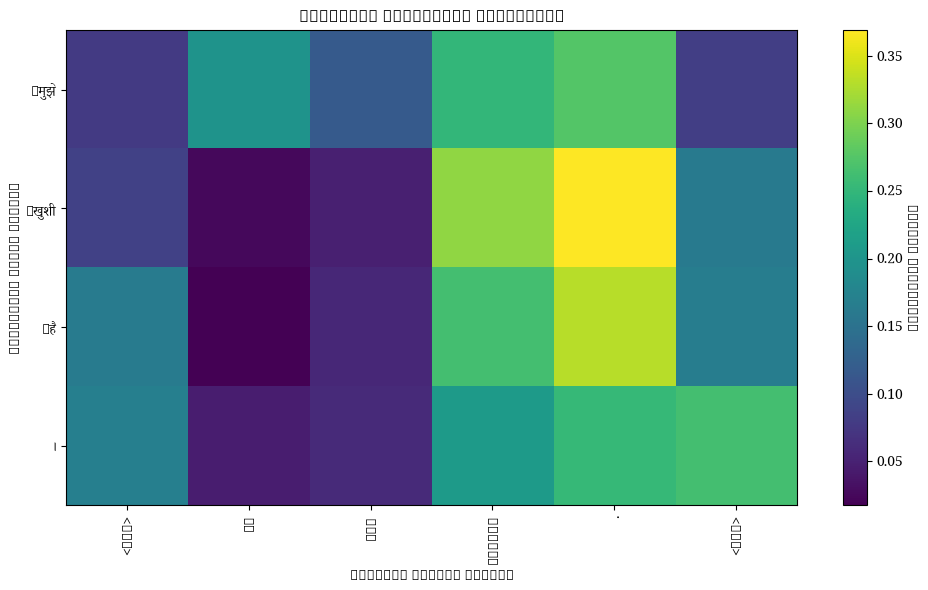

In [44]:
# ============================================================
# STEP 43: REGENERATE ATTENTION MAP WITH HINDI FONT
# ============================================================

attention_test_sentence = "I am happy."

translated_text, attention_matrix = translate_with_attention(
    sentence=attention_test_sentence,
    model=model,
    english_tokenizer=english_tokenizer,
    hindi_tokenizer=hindi_tokenizer,
    device=device
)

attention_save_path = os.path.join(
    ATTENTION_MAP_DIR,
    "attention_map_i_am_happy_fixed_font.png"
)

print("English :", attention_test_sentence)
print("Hindi   :", translated_text)

plot_attention_map(
    sentence=attention_test_sentence,
    translated_text=translated_text,
    attention_matrix=attention_matrix,
    english_tokenizer=english_tokenizer,
    hindi_tokenizer=hindi_tokenizer,
    save_path=attention_save_path
)

In [45]:
# ============================================================
# STEP 44: IMPROVED ATTENTION MAP WITH SEPARATE FONTS
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np
import os


# Hindi font
HINDI_FONT_PATH = (
    "/usr/share/fonts/truetype/noto/"
    "NotoSansDevanagari-Regular.ttf"
)

hindi_font = fm.FontProperties(
    fname=HINDI_FONT_PATH,
    size=11
)

# English font
english_font = fm.FontProperties(
    family="DejaVu Sans",
    size=11
)


def plot_attention_map_fixed(
    sentence,
    translated_text,
    attention_matrix,
    english_tokenizer,
    hindi_tokenizer,
    save_path=None
):

    # --------------------------------------------------------
    # SOURCE TOKENS
    # --------------------------------------------------------

    source_ids = encode_sentence(
        sentence,
        english_tokenizer
    )

    source_ids = [
        token_id
        for token_id in source_ids
        if token_id != PAD_ID
    ]

    source_tokens = []

    for token_id in source_ids:

        if token_id == BOS_ID:
            source_tokens.append("<BOS>")

        elif token_id == EOS_ID:
            source_tokens.append("<EOS>")

        else:
            source_tokens.append(
                english_tokenizer.id_to_piece(token_id)
            )

    # --------------------------------------------------------
    # TARGET TOKENS
    # --------------------------------------------------------

    target_ids = hindi_tokenizer.encode(
        translated_text,
        out_type=int
    )

    target_tokens = [
        hindi_tokenizer.id_to_piece(token_id)
        for token_id in target_ids
    ]

    rows_to_plot = min(
        len(target_tokens),
        attention_matrix.shape[0]
    )

    cols_to_plot = min(
        len(source_tokens),
        attention_matrix.shape[1]
    )

    attention_to_plot = (
        attention_matrix[
            :rows_to_plot,
            :cols_to_plot
        ]
        .cpu()
        .numpy()
    )

    target_tokens = target_tokens[:rows_to_plot]
    source_tokens = source_tokens[:cols_to_plot]

    # --------------------------------------------------------
    # CREATE PLOT
    # --------------------------------------------------------

    fig, ax = plt.subplots(
        figsize=(10, 6)
    )

    image = ax.imshow(
        attention_to_plot,
        aspect="auto"
    )

    # Color bar
    colorbar = fig.colorbar(
        image,
        ax=ax
    )

    colorbar.set_label(
        "Attention Weight",
        fontproperties=english_font
    )

    # English source tokens
    ax.set_xticks(
        range(len(source_tokens))
    )

    ax.set_xticklabels(
        source_tokens,
        rotation=90,
        fontproperties=english_font
    )

    # Hindi target tokens
    ax.set_yticks(
        range(len(target_tokens))
    )

    ax.set_yticklabels(
        target_tokens,
        fontproperties=hindi_font
    )

    # English labels/title
    ax.set_xlabel(
        "English Source Tokens",
        fontproperties=english_font
    )

    ax.set_ylabel(
        "Generated Hindi Tokens",
        fontproperties=english_font
    )

    ax.set_title(
        "Bahdanau Attention Alignment",
        fontproperties=english_font,
        fontsize=14
    )

    plt.tight_layout()

    # --------------------------------------------------------
    # SAVE
    # --------------------------------------------------------

    if save_path is not None:

        plt.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight"
        )

        print(
            "Final attention map saved at:",
            save_path
        )

    plt.show()


print("Improved attention-map function created successfully.")

Improved attention-map function created successfully.


English : I am happy.
Hindi   : मुझे खुशी है।


/tmp/ipykernel_1815/3349079343.py:166: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Devanagari.
  plt.tight_layout()
/tmp/ipykernel_1815/3349079343.py:166: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Devanagari.
  plt.tight_layout()
/tmp/ipykernel_1815/3349079343.py:166: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) Noto Sans Devanagari.
  plt.tight_layout()
/tmp/ipykernel_1815/3349079343.py:166: UserWarning: Glyph 108 (l) missing from font(s) Noto Serif Devanagari.
  plt.tight_layout()
/tmp/ipykernel_1815/3349079343.py:166: UserWarning: Glyph 112 (p) missing from font(s) Noto Serif Devanagari.
  plt.tight_layout()
/tmp/ipykernel_1815/3349079343.py:174: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Devanagari.
  plt.savefig(
/tmp/ipykernel_1815/3349079343.py:174: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Devanagari.
  plt.savefig(
/tmp/ipykernel_1815/3349079343.py:174: UserWarning: Glyph 9601 (\N{LOWER O

Final attention map saved at: /content/drive/MyDrive/NNDL_English_Hindi_Translator/results/attention_maps/attention_map_i_am_happy_final.png


/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Devanagari.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Devanagari.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) Noto Sans Devanagari.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 108 (l) missing from font(s) Noto Serif Devanagari.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 112 (p) missing from font(s) Noto Serif Devanagari.
  fig.canvas.print_figure(bytes_io, **kw)


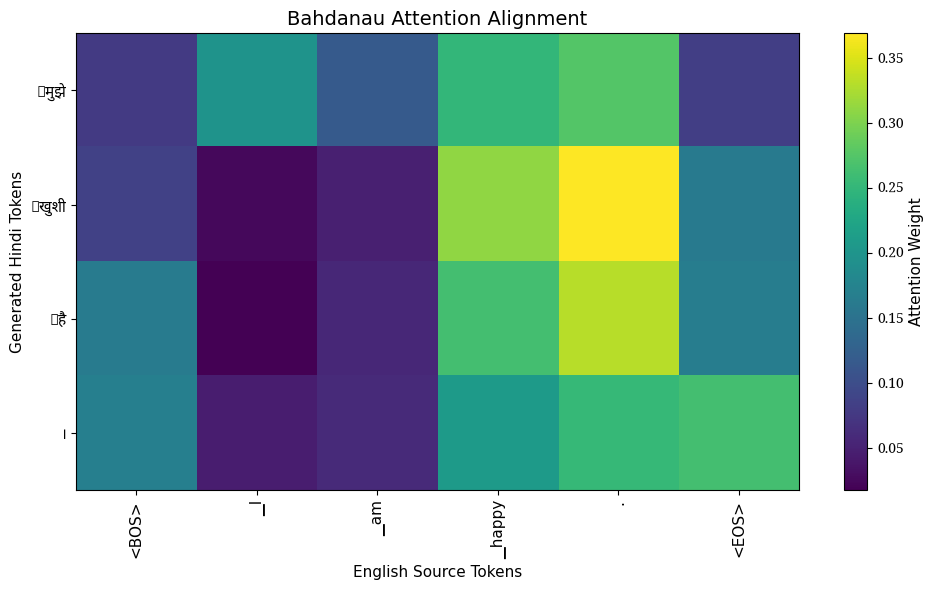

In [46]:
# ============================================================
# STEP 45: GENERATE FINAL CLEAN ATTENTION MAP
# ============================================================

attention_test_sentence = "I am happy."

translated_text, attention_matrix = translate_with_attention(
    sentence=attention_test_sentence,
    model=model,
    english_tokenizer=english_tokenizer,
    hindi_tokenizer=hindi_tokenizer,
    device=device
)

final_attention_path = os.path.join(
    ATTENTION_MAP_DIR,
    "attention_map_i_am_happy_final.png"
)

print("English :", attention_test_sentence)
print("Hindi   :", translated_text)

plot_attention_map_fixed(
    sentence=attention_test_sentence,
    translated_text=translated_text,
    attention_matrix=attention_matrix,
    english_tokenizer=english_tokenizer,
    hindi_tokenizer=hindi_tokenizer,
    save_path=final_attention_path
)

In [47]:
# ============================================================
# STEP 46: GENERATE VALIDATION PREDICTIONS FOR MODEL 2
# ============================================================

attention_validation_predictions = []

print("Generating validation predictions...")

for i in range(len(validation_df)):

    english_text = validation_df.iloc[i]["english"]
    reference_hindi = validation_df.iloc[i]["hindi"]

    predicted_hindi, _ = translate_with_attention(
        sentence=english_text,
        model=model,
        english_tokenizer=english_tokenizer,
        hindi_tokenizer=hindi_tokenizer,
        device=device
    )

    attention_validation_predictions.append({
        "english": english_text,
        "reference_hindi": reference_hindi,
        "predicted_hindi": predicted_hindi
    })


attention_predictions_df = pd.DataFrame(
    attention_validation_predictions
)

ATTENTION_PREDICTIONS_PATH = os.path.join(
    RESULTS_METRICS_DIR,
    "gru_attention_validation_predictions.csv"
)

attention_predictions_df.to_csv(
    ATTENTION_PREDICTIONS_PATH,
    index=False
)

print("Validation predictions generated successfully.")
print("Total predictions:", len(attention_predictions_df))
print("Saved at:", ATTENTION_PREDICTIONS_PATH)

Generating validation predictions...
Validation predictions generated successfully.
Total predictions: 520
Saved at: /content/drive/MyDrive/NNDL_English_Hindi_Translator/results/metrics/gru_attention_validation_predictions.csv


In [34]:
# ============================================================
# STEP 47: CALCULATE VALIDATION BLEU AND chrF FOR MODEL 2
# ============================================================

# Install sacreBLEU if needed
!pip -q install sacrebleu

import sacrebleu
import pandas as pd
import os


# ------------------------------------------------------------
# LOAD SAVED VALIDATION PREDICTIONS
# ------------------------------------------------------------

ATTENTION_PREDICTIONS_PATH = os.path.join(
    RESULTS_METRICS_DIR,
    "gru_attention_validation_predictions.csv"
)

attention_predictions_df = pd.read_csv(
    ATTENTION_PREDICTIONS_PATH
)

print("Validation predictions loaded successfully.")
print("Total predictions:", len(attention_predictions_df))


# ------------------------------------------------------------
# PREPARE REFERENCES AND PREDICTIONS
# ------------------------------------------------------------

predictions = (
    attention_predictions_df["predicted_hindi"]
    .fillna("")
    .astype(str)
    .tolist()
)

references = (
    attention_predictions_df["reference_hindi"]
    .fillna("")
    .astype(str)
    .tolist()
)


# ------------------------------------------------------------
# BLEU
# ------------------------------------------------------------

bleu_score = sacrebleu.corpus_bleu(
    predictions,
    [references]
).score


# ------------------------------------------------------------
# chrF
# ------------------------------------------------------------

chrf_score = sacrebleu.corpus_chrf(
    predictions,
    [references]
).score


print("\nMODEL 2 VALIDATION RESULTS")
print("-" * 40)

print(f"BLEU : {bleu_score:.4f}")
print(f"chrF : {chrf_score:.4f}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.6/129.6 kB 4.0 MB/s eta 0:00:00
Validation predictions loaded successfully.
Total predictions: 520

MODEL 2 VALIDATION RESULTS
----------------------------------------
BLEU : 3.2413
chrF : 20.6241


In [35]:
# ============================================================
# STEP 48: SAVE FINAL MODEL 2 METRICS
# ============================================================

model2_metrics = pd.DataFrame([
    {
        "model": "GRU + Bahdanau Attention",
        "decoding": "Greedy",
        "best_epoch": 4,
        "best_validation_loss": 6.520715561180102,
        "validation_bleu": bleu_score,
        "validation_chrf": chrf_score,
        "parameters": 20733569
    }
])

MODEL2_METRICS_PATH = os.path.join(
    RESULTS_METRICS_DIR,
    "gru_attention_validation_metrics.csv"
)

model2_metrics.to_csv(
    MODEL2_METRICS_PATH,
    index=False
)

print("Model 2 metrics saved successfully.")
print(MODEL2_METRICS_PATH)

model2_metrics

Model 2 metrics saved successfully.
/content/drive/MyDrive/NNDL_English_Hindi_Translator/results/metrics/gru_attention_validation_metrics.csv


,model,decoding,best_epoch,best_validation_loss,validation_bleu,validation_chrf,parameters
0,GRU + Bahdanau Attention,Greedy,4,6.520716,3.241286,20.624114,20733569
